In [3]:
# importing modules

import sys
import csv
import nmrglue as ng
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
dic,fid = ng.bruker.read('./')

In [5]:
# =============================================================================
# Define conditions
# =============================================================================

dwell_time=0.4e-6
dead_time=dic['acqus']['DE']*1e-6
p1=dic['acqus']['P'][1]*1e-6

In [6]:
fid_dig_filter_removed=ng.bruker.remove_digital_filter(dic,fid,truncate=True)

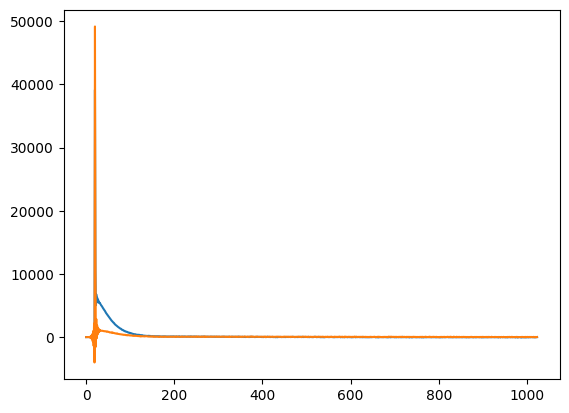

In [9]:
plt.plot(fid.real)
plt.plot(fid.imag)
plt.show()

In [10]:
ng.process.proc_autophase.manual_ps(fid,notebook=True)

interactive(children=(FloatSlider(value=-0.0015926535897929917, description='phcorr0', max=3.141592653589793, …

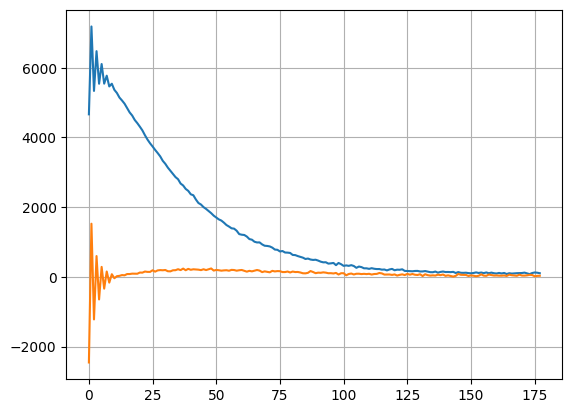

C:\Users\bidit\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\bidit\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


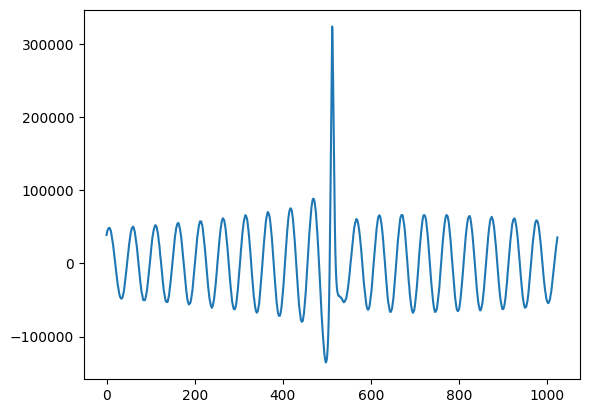

In [11]:
fid_phase_corrected=ng.proc_base.ps(fid, p0=-11, p1=-0.34)
plt.plot(fid_phase_corrected[22:200].real)
plt.plot(fid_phase_corrected[22:200].imag)
plt.grid()
plt.show()
spectra=ng.proc_base.fft(fid_phase_corrected)
plt.plot(spectra)
plt.show()

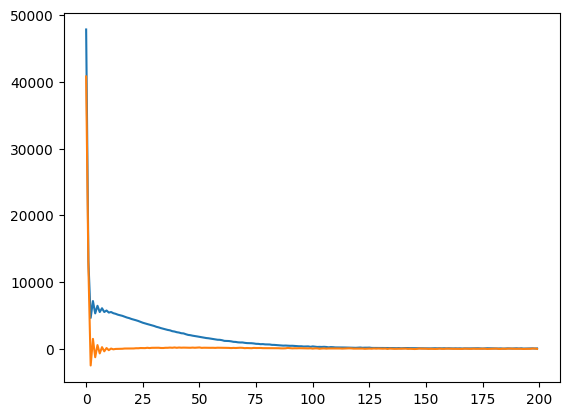

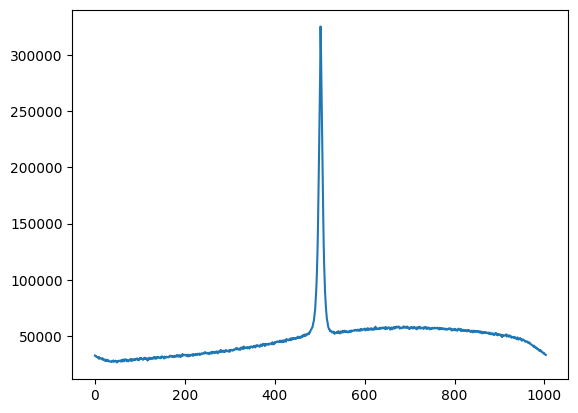

In [12]:
fid_group_delay_corrected= fid_phase_corrected[20:]
plt.plot(fid_group_delay_corrected[:200].real)
plt.plot(fid_group_delay_corrected[:200].imag)
plt.show()
spectra=ng.proc_base.fft(fid_group_delay_corrected)
plt.plot(spectra)
plt.show()

In [13]:
time_axis= p1/2 + dead_time + dwell_time * (np.arange(len(fid_group_delay_corrected))+1)
print(time_axis)

[3.100e-06 3.500e-06 3.900e-06 ... 4.035e-04 4.039e-04 4.043e-04]


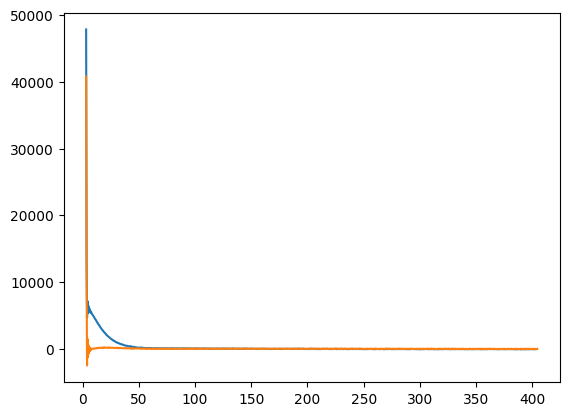

In [15]:
df_fid=pd.DataFrame()
df_fid["time"]=time_axis*1e6
df_fid["real_intensity"]=fid_group_delay_corrected.real
df_fid["imaginary_intensity"]=fid_group_delay_corrected.imag
df_fid["magnitude"]=np.sqrt(df_fid["real_intensity"]**2+df_fid["imaginary_intensity"]**2)
plt.plot(df_fid['time'],df_fid['real_intensity'])
plt.plot(df_fid['time'],df_fid['imaginary_intensity'])
plt.show()

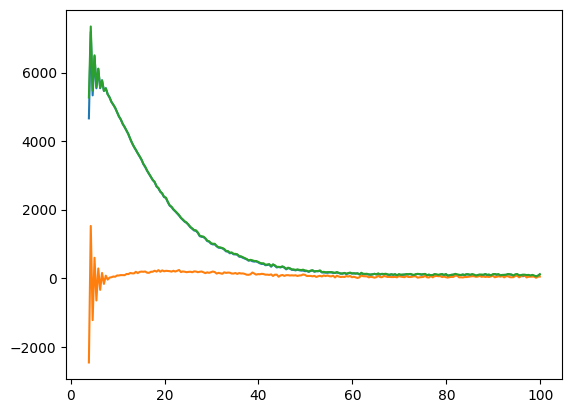

In [16]:
fit_fid=df_fid[(df_fid['time']<=100)&(df_fid['time']>=3.5)]
plt.plot(fit_fid['time'],fit_fid['real_intensity'])
plt.plot(fit_fid['time'],fit_fid['imaginary_intensity'])
plt.plot(fit_fid['time'],fit_fid['magnitude'])
plt.show()

In [17]:
fit_fid.to_csv("clean_fid.txt",index=False,header=False)